In [1]:
!pip install yfinance

**Import library yang dibutuhkan**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

**install dan ambil data BBCA**

In [3]:
df = yf.download("BBCA.JK", start="2022-01-01", end="2024-01-01")

print(df.shape)
print(df.head())

/tmp/ipykernel_55/2912374900.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BBCA.JK", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

(485, 5)
Price             Close         High          Low         Open     Volume
Ticker          BBCA.JK      BBCA.JK      BBCA.JK      BBCA.JK    BBCA.JK
Date                                                                     
2022-01-03  6297.415527  6361.894185  6275.922642  6297.415527   54287400
2022-01-04  6361.895020  6404.880797  6297.416354  6297.416354   70624000
2022-01-05  6404.880859  6469.359526  6340.402193  6404.880859   76164900
2022-01-06  6426.374512  6469.360294  6383.388729  6447.867403   63657100
2022-01-07  6576.824707  6619.810489  6447.867360  6490.853142  143433300


**mendefinisikan kolom bbca**

In [4]:
df.columns = df.columns.get_level_values(0)
print(df.columns)
print(df.head())

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price             Close         High          Low         Open     Volume
Date                                                                     
2022-01-03  6297.415527  6361.894185  6275.922642  6297.415527   54287400
2022-01-04  6361.895020  6404.880797  6297.416354  6297.416354   70624000
2022-01-05  6404.880859  6469.359526  6340.402193  6404.880859   76164900
2022-01-06  6426.374512  6469.360294  6383.388729  6447.867403   63657100
2022-01-07  6576.824707  6619.810489  6447.867360  6490.853142  143433300


In [5]:
close = df['Close']
df['log_return'] = np.log(close/close.shift(1))

print(df['log_return'].describe())
print("\nskewness:", round(df['log_return'].skew(), 4))
print("kurtosis:", round(df['log_return'].kurt(), 4))

count    484.000000
mean       0.000606
std        0.012909
min       -0.066798
25%       -0.006585
50%        0.000000
75%        0.006999
max        0.042319
Name: log_return, dtype: float64

skewness: -0.1405
kurtosis: 2.0906


**log return**,
BBCA periode Jan 2022 – Jan 2024 bergerak relatif normal dan stabil, sedikit cenderung turun lebih dalam dari naik, tapi tidak ada kejadian ekstrem yang signifikan.

**visualisasi**

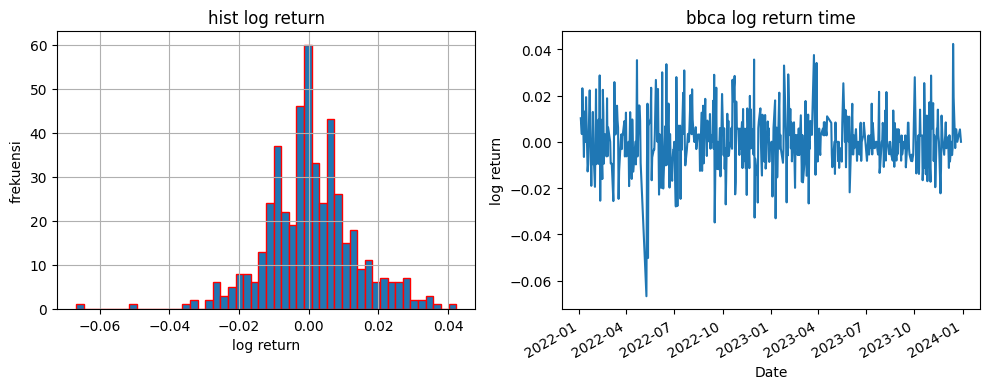

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))

#histogram return
plt.subplot(1, 2, 1)
df['log_return'].hist(bins = 50, edgecolor='red')
plt.title('hist log return')
plt.xlabel('log return')
plt.ylabel('frekuensi')

#time series log return
plt.subplot(1, 2, 2)
df['log_return'].plot()
plt.title('bbca log return time')
plt.xlabel('Date')
plt.ylabel('log return')

plt.tight_layout()
plt.show()

* Histogram — bentuknya seperti lonceng tapi tidak sempurna, ada ekor kiri yang sedikit lebih panjang. Itu konsisten dengan skewness -0.145 yang didapat tadi.
* Time series — mengkonfirmasi dua periode volatil itu. 2022 awal sampai pertengahan itu bertepatan dengan dampak perang Rusia-Ukraina dan kenaikan suku bunga The Fed agresif. Akhir 2023 ada tekanan global lagi dari kekhawatiran resesi AS. BBCA sebagai saham perbankan sensitif terhadap isu suku bunga — itu sebabnya volatilitasnya naik di periode itu.

**outlier**

In [7]:
df['zscore'] = (df['log_return'] - df['log_return'].mean())/df['log_return'].std()

#tampilan
outliers = df[df['zscore'].abs() > 3]
print("jumlah outliers", len(outliers))
print(outliers[['Close', 'log_return', 'zscore']].sort_values('zscore'))

jumlah outliers 3
Price             Close  log_return    zscore
Date                                         
2022-05-09  6633.973633   -0.066798 -5.221351
2022-05-12  6350.284180   -0.050262 -3.940419
2023-12-14  8127.617676    0.042319  3.231344


1. 2022-05-09 dan 2022-05-12, disini ada masalah energi. dimana uni eropa membuat proposal untuk tidak lagi mengimport minyak dari rusia karena manuver panas rusia ke ukraine yang menyebabkan hanrga minyak melambung dan the fed menaikan suku bunga 50 bps sebersar 1,00%.  bad news (perang, minyak, Fed hawkish) → investor kabur dari ekuitas
2. 2023-12-14, disini the fed menahan suku bunga di angka 5.5 %. hal ini menurunkan yield us treasury dan mendorong reli tajam ke ekuitas global serta adanya red sea crisis. pada log return di tahun 2022 minus sedangkan pada 2023 positif.  good news (Fed pivot signal) → investor masuk balik ke ekuitas

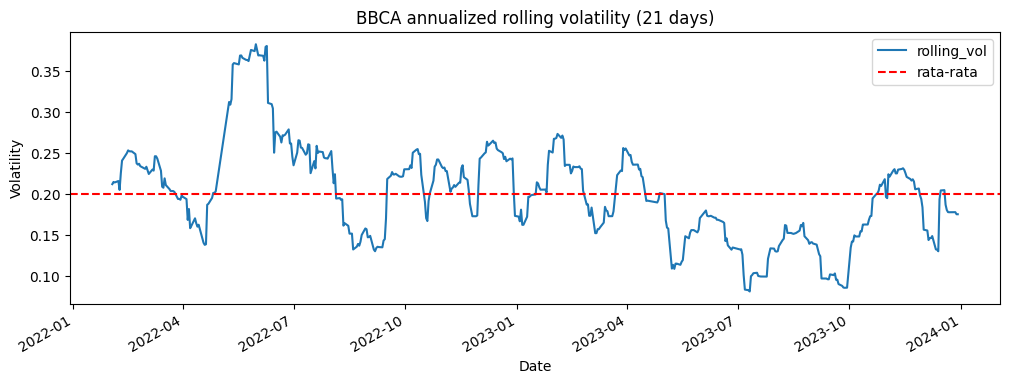

rata rata volatilitas tahunan: 19.95%


In [8]:
df['rolling_vol'] = df['log_return'].rolling(window=21).std() * np.sqrt(252)

plt.figure(figsize=(12, 4))
df['rolling_vol'].plot()
plt.title('BBCA annualized rolling volatility (21 days)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.axhline(df['rolling_vol'].mean(), color='red', linestyle='--', label='rata-rata')
plt.legend()
plt.show()

print(f"rata rata volatilitas tahunan: {df['rolling_vol'].mean():.2%}")

## Rolling Volatility Analysis
Rata-rata volatilitas tahunan BBCA periode 2022-2024 adalah 19.95%.
Terdapat dua periode volatilitas ekstrem:
- Mei 2022: dipicu kenaikan Fed Funds Rate dan krisis energi Eropa
- Desember 2023: sinyal pivot Fed mendorong reli tajam

Secara umum volatilitas 2023 lebih rendah dari 2022, 
mengindikasikan stabilisasi pasar pasca ketidakpastian global.

In [9]:
from statsmodels.tsa.stattools import adfuller
# adf test close
result_price = adfuller(df['Close'])
print("===ADF Test Harga Close===")
print(f"ADF statistic:{result_price[0]:.4f}")
print(f"p-value: {result_price[1]:.4f}")
print("kesimpulan:", {'stasioner' if result_price[1] < 0.05 else "tidak stasioner"})

print()
# adf test log return
result_ret = adfuller(df['log_return'].dropna())
print("===ADF Test log return===")
print(f"ADF statistic:{result_ret[0]:.4f}")
print(f"p-value: {result_ret[1]:.4f}")
print("kesimpulan:", {'stasioner' if result_ret[1] < 0.05 else "tidak stasioner"})

===ADF Test Harga Close===
ADF statistic:-1.5312
p-value: 0.5180
kesimpulan: {'tidak stasioner'}

===ADF Test log return===
ADF statistic:-25.2593
p-value: 0.0000
kesimpulan: {'stasioner'}


Harga Close p-value 0.518 jauh di atas 0.05 — gagal tolak hipotesis nol, artinya ada unit root, data tidak stasioner. Harga saham "mengembara" tanpa mean yang tetap, tidak bisa dimodelkan langsung.
Log Returns p-value 0.000 dan ADF statistic -25.259 yang sangat negatif — tolak hipotesis nol dengan sangat kuat. Data stasioner, mean dan variansinya stabil.

**ACF & PACF**

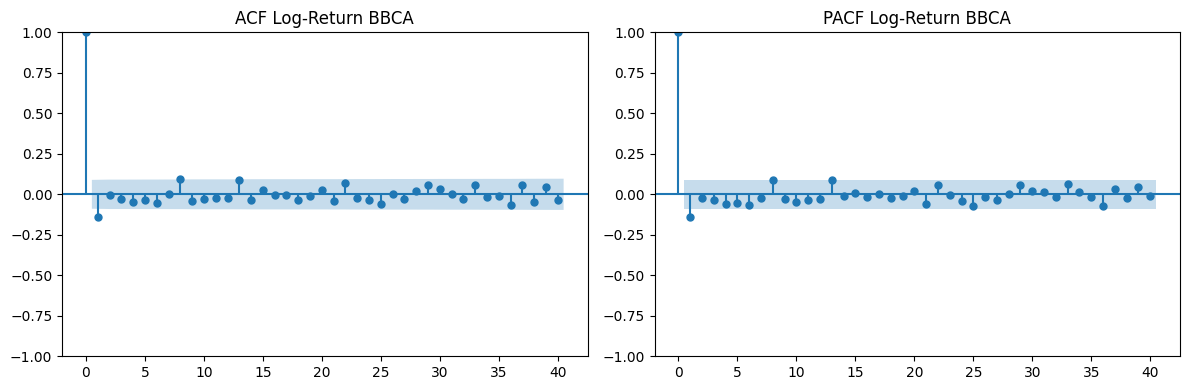

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1,2, figsize=(12,4))

plot_acf(df['log_return'].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF Log-Return BBCA")

plot_pacf(df['log_return'].dropna(), lags=40, ax=axes[1])
axes[1].set_title("PACF Log-Return BBCA")

plt.tight_layout()
plt.show()

**Arima**

In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['log_return'].dropna(), order=(1,0,1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                  484
Model:                 ARIMA(1, 0, 1)   Log Likelihood                1424.042
Date:                Sun, 05 Apr 2026   AIC                          -2840.085
Time:                        03:08:38   BIC                          -2823.357
Sample:                             0   HQIC                         -2833.512
                                - 484                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.222      0.222      -0.000       0.002
ar.L1          0.0484      0.265      0.183      0.855      -0.470       0.567
ma.L1         -0.1933      0.262     -0.738      0.4

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## ARIMA(1,0,1) Results & Interpretation

Model ARIMA(1,0,1) dibangun sebagai baseline untuk log returns BBCA.

Hasil:
- ar.L1 p-value: 0.855 → tidak signifikan
- ma.L1 p-value: 0.460 → tidak signifikan
- Kurtosis residual: 5.13 (fat tail — ada struktur yang belum tertangkap)
- Jarque-Bera p-value: 0.00 → residual tidak normal

Kesimpulan:
Log returns BBCA mendekati white noise — tidak ada autokorelasi
linear yang bisa dieksploitasi. Namun kurtosis residual yang tinggi
mengindikasikan volatility clustering yang membutuhkan model GARCH.
ARIMA berfungsi sebagai baseline yang dikonfirmasi tidak memadai,
sesuai dengan pendekatan de Prado sebelum masuk ke model yang lebih kompleks.

Next step: GARCH modeling untuk volatility forecasting.

In [12]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.2 MB/s eta 0:00:00a 0:00:01


In [13]:
from arch import arch_model

# definisi model arch(1,1)
#p = 1 hasil dari volatilias kemarin yang mempengaruhi hari ini
#q = 1 shock kemarin mempengaruhi volatilitas hari ini
garch = arch_model(
    df['log_return'].dropna() * 100,
    vol = 'Garch',
    p = 1,
    q = 1
)

result_garch = garch.fit(disp='off')
print(result_garch.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -801.413
Distribution:                  Normal   AIC:                           1610.83
Method:            Maximum Likelihood   BIC:                           1627.55
                                        No. Observations:                  484
Date:                Sun, Apr 05 2026   Df Residuals:                      483
Time:                        03:08:43   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0732  5.613e-02      1.304      0.192 [-3.68

In [14]:
alpha = 0.0686
beta = 0.8591
persistance = alpha + beta
print(f'volatility persistance: {persistance:.4f}')

volatility persistance: 0.9277


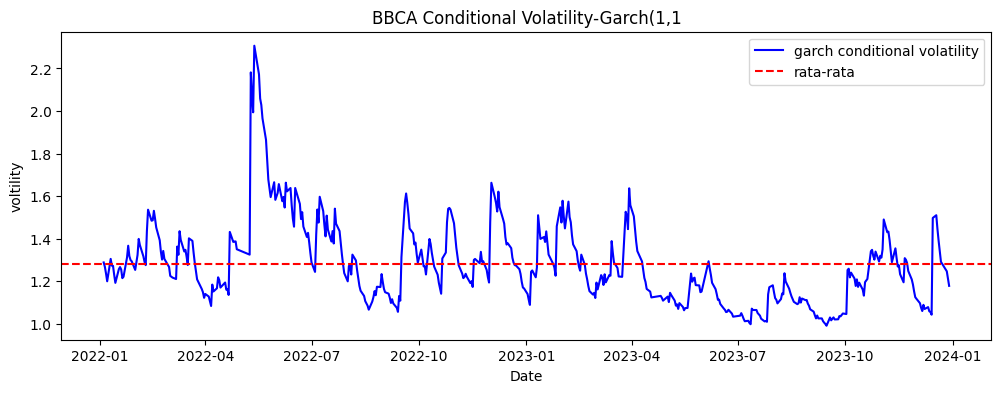

rata-rata conditional volatility:1.2811
volatility persistance:0.9277


In [15]:
cond_vol = result_garch.conditional_volatility
plt.figure(figsize=(12,4))
plt.plot(df['log_return'].dropna().index, cond_vol,
        label = 'garch conditional volatility', color = 'blue')
plt.axhline(y = cond_vol.mean(), color='red',
           linestyle='--', label='rata-rata')
plt.title('BBCA Conditional Volatility-Garch(1,1')
plt.xlabel('Date')
plt.ylabel('voltility')
plt.legend()
plt.show()

print(f'rata-rata conditional volatility:{cond_vol.mean():.4f}')
print(f'volatility persistance:{0.0686+0.8591:.4f}')

## GARCH(1,1) - Volatility Modeling

Model GARCH(1,1) dibangun untuk menangkap volatility clustering
yang tidak bisa ditangkap ARIMA.

Hasil:
- omega : 0.1217 (volatilitas dasar)
- alpha : 0.0686 (pengaruh shock kemarin)
- beta  : 0.8591 (persistensi volatilitas) ← signifikan, p≈0
- Persistence (α+β): 0.9277

Interpretasi:
92.77% volatilitas hari ini dibawa ke hari berikutnya.
BBCA memiliki volatilitas yang sangat persisten — sekali bergejolak,
efeknya bertahan lama. Terbukti dari spike Mei 2022 yang baru mereda
di akhir 2022, dan spike Desember 2023 yang muncul kembali di awal 2024.

GARCH lebih responsif dari rolling volatility manual karena memberikan
bobot lebih besar ke kejadian terbaru — inilah kenapa GARCH menjadi
standar industri untuk risk management.

In [16]:
forecast = result_garch.forecast(horizon=5)

vol_forecast = np.sqrt(forecast.variance.values[-1])/100
print('forecast volatilitas BBCA 5 hari ke depan:')
print('=' * 45)
for i, vol in enumerate(vol_forecast, 1):
    print(f'Hari {i}: ({vol}:.4f ({vol*100:.2f}% per hari')

print(f'\nRata-rata volatilitas: {vol_forecast.mean()*100:.2f}% per hari')
print(f'volatilitas aktual: 1.28% per hari (baseline)')

forecast volatilitas BBCA 5 hari ke depan:
Hari 1: (0.011468175337550672:.4f (1.15% per hari
Hari 2: (0.011583608853895038:.4f (1.16% per hari
Hari 3: (0.011689680478584277:.4f (1.17% per hari
Hari 4: (0.011787232554935988:.4f (1.18% per hari
Hari 5: (0.011877017862667705:.4f (1.19% per hari

Rata-rata volatilitas: 1.17% per hari
volatilitas aktual: 1.28% per hari (baseline)


## Volatility Forecasting - GARCH(1,1)

Forecast volatilitas BBCA 5 hari ke depan:
- Hari 1: 1.15% | Hari 2: 1.16% | Hari 3: 1.17%
- Hari 4: 1.18% | Hari 5: 1.19%
- Rata-rata forecast: 1.17% per hari

Interpretasi:
Forecast di bawah baseline historis 1.28% — pasar diprediksi
lebih tenang dari rata-rata. Pola naik bertahap (1.15% → 1.19%)
mencerminkan mean reversion akibat persistence tinggi (0.9277):
volatilitas bergerak perlahan kembali ke rata-rata jangka panjang.

Implikasi praktis:
Kondisi aman untuk posisi normal. Tidak ada sinyal volatilitas
ekstrem di 5 hari ke depan berdasarkan data historis Jan 2022–Jan 2024.

In [21]:
df['dollar_volume'] = df['Close']*df['Volume']

threshold = 500_000_000_000

dollar_bars = []
cumulative = 0
bar_open = df['Close'].iloc[0]
bar_high = df['Close'].iloc[0]
bar_low = df['Close'].iloc[0]
bar_vol = 0

for idx, row in df.iterrows():
    cumulative += row['dollar_volume']
    bar_high = max(bar_high, row['Close'])
    bar_low = min(bar_low, row['Close'])
    bar_vol += row['Volume']

    if cumulative >= threshold:
        dollar_bars.append({
            'date': idx,
            'open': bar_open,
            'high': bar_high,
            'low': bar_low,
            'close': row['Close'],
            'volume': bar_vol,
            'dollar_volume': cumulative
        })

        cumulative = 0
        bar_open = row['Close']
        bar_high = row['Close']
        bar_low = row['Close']
        bar_vol = 0
db = pd.DataFrame(dollar_bars)
print(f'time bars: {len(df)} baris')
print(f'dollar bars: {len(db)} baris')
print()
print(db.head(10))

time bars: 485 baris
dollar bars: 355 baris

        date         open         high          low        close       volume  \
0 2022-01-04  6297.415527  6361.895020  6297.415527  6361.895020  124911400.0   
1 2022-01-06  6361.895020  6426.374512  6361.895020  6426.374512  139822000.0   
2 2022-01-07  6426.374512  6576.824707  6426.374512  6576.824707  143433300.0   
3 2022-01-11  6576.824707  6619.809570  6533.838379  6619.809570  155686500.0   
4 2022-01-13  6619.809570  6619.809570  6619.809570  6619.809570  112631200.0   
5 2022-01-17  6619.809570  6748.767090  6619.809570  6662.795410  129801300.0   
6 2022-01-19  6662.795410  6662.795410  6598.316895  6598.316895  131866000.0   
7 2022-01-21  6598.316895  6834.738770  6598.316895  6834.738770  123296000.0   
8 2022-01-25  6834.738770  6834.738770  6684.288574  6684.288574  147075200.0   
9 2022-01-27  6684.288574  6705.780762  6619.809570  6705.780762  125295300.0   

   dollar_volume  
0   7.911728e+11  
1   8.969115e+11  
2   9.

## Dollar Bars - De Prado Alternative Data Structure

Time bars : 485 bars (1 bar per hari tanpa peduli aktivitas)
Dollar bars: 355 bars (1 bar per 500 miliar rupiah diperdagangkan)

Kenapa dollar bars lebih baik:
Setiap bar merepresentasikan aktivitas ekonomi yang setara.
Hari sepi dan hari ramai tidak diperlakukan sama.
Model ML yang dilatih di dollar bars lebih stabil dan less biased
dibanding model yang dilatih di time bars biasa.

Ini adalah konsep fundamental dari Advances in Financial Machine
Learning (de Prado, 2018) — fondasi quant modern.

Triple Barrier Method

In [22]:
import numpy as np
import pandas as pd

def triple_barrier(returns, upper=0.02, lower=-0.02, max_days=10):
    """
    upper    : take profit threshold (2%)
    lower    : stop loss threshold (-2%)
    max_days : time barrier (10 hari)
    """
    labels = []
    
    for i in range(len(returns)):
        cumret = 0
        label = 0  # default: time barrier hit
        
        for j in range(1, max_days + 1):
            if i + j >= len(returns):
                break
                
            cumret += returns.iloc[i + j]
            
            if cumret >= upper:
                label = 1   # take profit hit
                break
            elif cumret <= lower:
                label = -1  # stop loss hit
                break
        
        labels.append(label)
    
    return pd.Series(labels, index=returns.index)

# Apply ke log returns BBCA
db['log_return'] = np.log(db['close'] / db['close'].shift(1))
db['label'] = triple_barrier(
    db['log_return'].dropna(),
    upper=0.02,
    lower=-0.02,
    max_days=10
)

# Lihat distribusi label
print("Distribusi Label:")
print(db['label'].value_counts())
print()
print(f"Buy  ( 1): {(db['label']==1).sum()} bars ({(db['label']==1).mean()*100:.1f}%)")
print(f"Sell (-1): {(db['label']==-1).sum()} bars ({(db['label']==-1).mean()*100:.1f}%)")
print(f"Hold ( 0): {(db['label']==0).sum()} bars ({(db['label']==0).mean()*100:.1f}%)")

Distribusi Label:
label
 1.0    175
-1.0    141
 0.0     38
Name: count, dtype: int64

Buy  ( 1): 175 bars (49.3%)
Sell (-1): 141 bars (39.7%)
Hold ( 0): 38 bars (10.7%)


## Triple Barrier Method - De Prado Labeling

Parameter:
- Take profit barrier : +2% (upper)
- Stop loss barrier   : -2% (lower)  
- Time barrier        : 10 hari

Hasil distribusi label:
- Buy  ( 1): 175 bars (49.3%) — harga naik 2% dalam 10 hari
- Sell (-1): 141 bars (39.7%) — harga turun 2% dalam 10 hari
- Hold ( 0):  38 bars (10.7%) — harga stagnan dalam range ±2%

Interpretasi:
BBCA adalah saham aktif — jarang stagnan lebih dari 10 hari
tanpa menyentuh barrier ±2%. Bias upward terdeteksi (Buy > Sell),
konsisten dengan tren positif BBCA sebagai saham blue chip perbankan.

Class imbalance terdeteksi — Hold hanya 10.7%.
Perlu penanganan khusus (SMOTE/class weighting) sebelum training ML.

feature engineering

In [28]:
db = db.copy()

db['log_return'] = np.log(db['close']/db['close'].shift(1))

db['mom_5'] = db['close'].pct_change(5)
db['mom_10'] = db['close'].pct_change(10)

db['vol_10'] = db['log_return'].rolling(10).std()

db['vol_ratio'] = db['volume'] / db['volume'].rolling(10).mean()

db['ma_20'] = db['close'].rolling(20).mean()
db['ma_dist'] = (db['close'] - db['ma_20']) / db['ma_20']

db = db.dropna()

features = ['log_return', 'mom_5', 'mom_10', 'vol_10', 'vol_ratio', 'ma_20', 'ma_dist']
print(f'total data setelah feature engineering: {len(db)} bars')
print()
print(db[features].describe().round(4))

total data setelah feature engineering: 298 bars

       log_return     mom_5    mom_10    vol_10  vol_ratio      ma_20  \
count    298.0000  298.0000  298.0000  298.0000   298.0000   298.0000   
mean       0.0008    0.0037    0.0073    0.0142     0.9863  7530.1914   
std        0.0144    0.0280    0.0381    0.0053     0.4135   570.0130   
min       -0.0503   -0.1128   -0.0976    0.0037     0.4305  6368.8329   
25%       -0.0081   -0.0139   -0.0194    0.0101     0.7554  7310.4861   
50%        0.0000    0.0029    0.0068    0.0140     0.8934  7592.1849   
75%        0.0085    0.0214    0.0326    0.0178     1.1134  8032.4703   
max        0.0394    0.0717    0.1210    0.0317     4.4883  8283.4285   

        ma_dist  
count  298.0000  
mean     0.0061  
std      0.0281  
min     -0.0694  
25%     -0.0140  
50%      0.0054  
75%      0.0246  
max      0.0745  


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Siapkan X dan y
features = ['log_return', 'mom_5', 'mom_10', 'vol_10', 'vol_ratio', 'ma_dist']
X = db[features]
y = db['label']

# Handle class imbalance dengan class weighting
classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

# Time Series Split — WAJIB untuk data finansial
# Jangan pakai random split — itu look-ahead bias
tscv = TimeSeriesSplit(n_splits=5)

# Training & evaluasi
all_reports = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight=class_weight,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n=== Fold {fold} ===")
    print(classification_report(y_test, y_pred, 
          target_names=['Sell', 'Hold', 'Buy']))

Class weights: {np.float64(-1.0): np.float64(0.8790560471976401), np.float64(0.0): np.float64(2.684684684684685), np.float64(1.0): np.float64(0.6711711711711712)}

=== Fold 1 ===
              precision    recall  f1-score   support

        Sell       0.20      0.06      0.09        17
        Hold       0.00      0.00      0.00         4
         Buy       0.55      0.86      0.67        28

    accuracy                           0.51        49
   macro avg       0.25      0.31      0.25        49
weighted avg       0.38      0.51      0.41        49



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


=== Fold 2 ===
              precision    recall  f1-score   support

        Sell       0.28      0.22      0.24        23
        Hold       0.00      0.00      0.00         1
         Buy       0.39      0.48      0.43        25

    accuracy                           0.35        49
   macro avg       0.22      0.23      0.22        49
weighted avg       0.33      0.35      0.33        49


=== Fold 3 ===
              precision    recall  f1-score   support

        Sell       0.38      0.50      0.43        18
        Hold       0.00      0.00      0.00         3
         Buy       0.56      0.50      0.53        28

    accuracy                           0.47        49
   macro avg       0.31      0.33      0.32        49
weighted avg       0.46      0.47      0.46        49



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


=== Fold 4 ===
              precision    recall  f1-score   support

        Sell       0.00      0.00      0.00        17
        Hold       0.00      0.00      0.00        20
         Buy       0.28      0.83      0.42        12

    accuracy                           0.20        49
   macro avg       0.09      0.28      0.14        49
weighted avg       0.07      0.20      0.10        49


=== Fold 5 ===
              precision    recall  f1-score   support

        Sell       0.50      0.68      0.58        22
        Hold       0.50      0.11      0.18         9
         Buy       0.41      0.39      0.40        18

    accuracy                           0.47        49
   macro avg       0.47      0.39      0.39        49
weighted avg       0.47      0.47      0.44        49



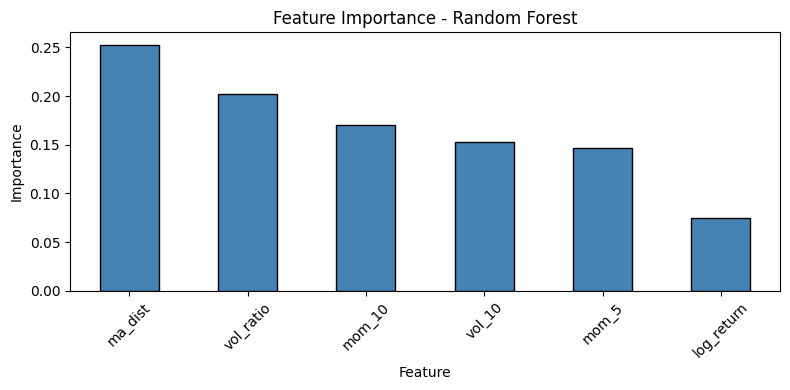

ma_dist       0.252862
vol_ratio     0.202407
mom_10        0.170661
vol_10        0.153251
mom_5         0.146349
log_return    0.074469
dtype: float64


In [30]:
# Feature importance — fitur mana yang paling berguna?
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(feature_importance)